In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

In [11]:
X, y = make_moons(
    n_samples = 500,
    noise = 0.1,
    random_state = 42
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<Axes: >

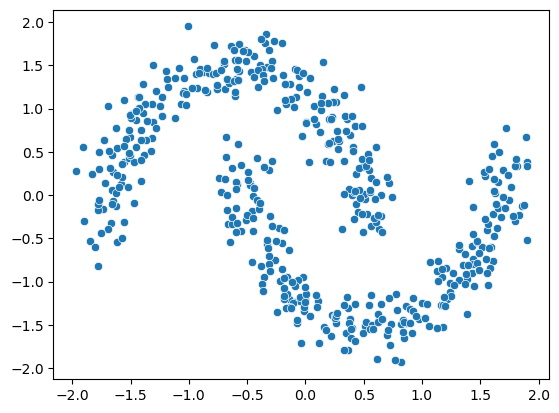

In [12]:
sns.scatterplot(x = X_scaled[:,0], y = X_scaled[:,1])

In [22]:
#dbscan
dbscan = DBSCAN(
    eps = 0.18,
    min_samples = 4
)

<Axes: >

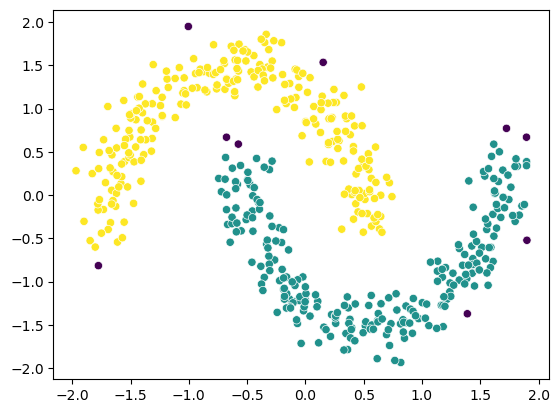

In [23]:
labels = dbscan.fit_predict(X_scaled)
sns.scatterplot(x = X_scaled[:,0], y = X_scaled[:,1], c = labels)

In [29]:
#Isolation forest it is kind of ensemble technique
df = pd.read_csv("thyroid.csv")
X = df.drop("binaryClass", axis = 1)
y = df["binaryClass"]

In [31]:
X_scaled = scaler.fit_transform(X)

In [39]:
from sklearn.ensemble import IsolationForest
IF = IsolationForest(
    n_estimators = 200,
    contamination = 0.36,
    random_state = 42
)
labels = IF.fit_predict(X_scaled)

In [40]:
#visualize the data
from sklearn.decomposition import PCA
pca = PCA(
    n_components = 2,
)
X_pca = pca.fit_transform(X_scaled)


Text(0, 0.5, 'PC2')

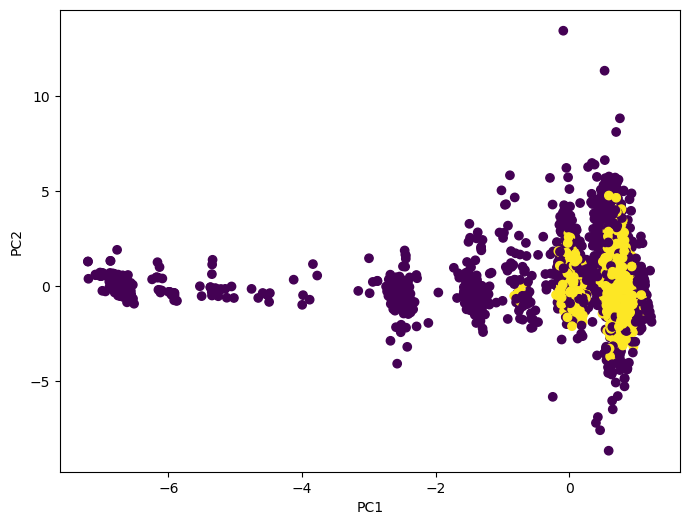

In [41]:
plt.figure(figsize = (8,6))
plt.scatter(x = X_pca[:,0], y = X_pca[:,1], c = labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [44]:
#anomaly detection using LOF (local outlier factor)
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(contamination = 0.36)
labels = lof.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

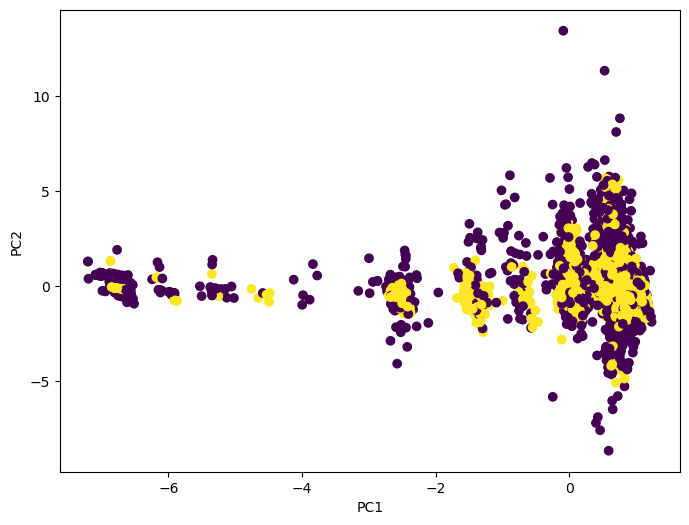

In [45]:
plt.figure(figsize = (8,6))
plt.scatter(x = X_pca[:,0], y = X_pca[:,1], c = labels)
plt.xlabel("PC1")
plt.ylabel("PC2")